In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving in-vehicle-coupon-recommendation.xlsx to in-vehicle-coupon-recommendation (3).xlsx


In [ ]:
df = pd.read_excel("in-vehicle-coupon-recommendation.xlsx")

In [ ]:
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [ ]:
df.shape

(12684, 26)

In [ ]:
df.isnull().sum()

,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


In [ ]:
# Filtering out columns with >25% nulls
df.columns[df.isnull().mean() > 0.25]

Index(['car'], dtype='object')

In [ ]:
# Removing sparse columns
spars_cols = df.columns[df.isnull().mean() > 0.25]
df = df.drop(columns=spars_cols)

In [ ]:
df.shape

(12684, 25)

In [ ]:
# Percentage of null values per column
null_percentage = df.isnull().mean()
null_percentage_cols = null_percentage[null_percentage < 0.25]
print(null_percentage_cols)

destination             0.000000
passanger               0.000000
weather                 0.000000
temperature             0.000000
time                    0.000000
coupon                  0.000000
expiration              0.000000
gender                  0.000000
age                     0.000000
maritalStatus           0.000000
has_children            0.000000
education               0.000000
occupation              0.000000
income                  0.000000
Bar                     0.008436
CoffeeHouse             0.017108
CarryAway               0.011905
RestaurantLessThan20    0.010249
Restaurant20To50        0.014901
toCoupon_GEQ5min        0.000000
toCoupon_GEQ15min       0.000000
toCoupon_GEQ25min       0.000000
direction_same          0.000000
direction_opp           0.000000
Y                       0.000000
dtype: float64


In [ ]:
# List of features with remaining null values
nv_features = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

# Replacing null values with the mode
for column in nv_features:
    df[column].fillna(df[column].mode()[0], inplace=True)

/tmp/ipython-input-2696755424.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()

,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


In [ ]:
df.rename(columns={
    'passanger': 'passenger',
    'RestaurantLessThan20': 'restaurant_visits_(<$20)',
    'Restaurant20To50': 'restaurant_visits_($20-$50)',
    'maritalStatus': 'marital_status',
    'Bar': 'bar_visits',
    'CoffeeHouse': 'coffee_house_visits',
    'CarryAway': 'take_out_frequency',
    'coupon': 'coupon_category',
    'expiration': 'coupon_expiry',
    'Y': 'accepted_coupon?'
    }, inplace=True)

In [ ]:
df.rename(columns={
    'toCoupon_GEQ5min': 'coupon_5',
    'toCoupon_GEQ15min': 'coupon_15',
    'toCoupon_GEQ25min': 'coupon_25'
}, inplace=True)

In [ ]:
df.columns

Index(['destination', 'passenger', 'weather', 'temperature', 'time',
       'coupon_category', 'coupon_expiry', 'gender', 'age', 'marital_status',
       'has_children', 'education', 'occupation', 'income', 'bar_visits',
       'coffee_house_visits', 'take_out_frequency', 'restaurant_visits_(<$20)',
       'restaurant_visits_($20-$50)', 'coupon_5', 'coupon_15', 'coupon_25',
       'direction_same', 'direction_opp', 'accepted_coupon?'],
      dtype='object')

In [ ]:
df.dtypes

,0
destination,object
passenger,object
weather,object
temperature,int64
time,object
coupon_category,object
coupon_expiry,object
gender,object
age,object
marital_status,object


In [ ]:
df['age'] = df['age'].replace({'below21': 20, '50plus': 55}).astype(int)

/tmp/ipython-input-1747830567.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['age'] = df['age'].replace({'below21': 20, '50plus': 55}).astype(int)


In [ ]:
# Convert numeric value containing columns from object into integars

df['age'] = pd.to_numeric(df['age'], errors='ignore').astype('Int64')

df.dtypes

/tmp/ipython-input-2891112710.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df['age'] = pd.to_numeric(df['age'], errors='ignore').astype('Int64')


,0
destination,object
passenger,object
weather,object
temperature,int64
time,object
coupon_category,object
coupon_expiry,object
gender,object
age,Int64
marital_status,object


In [ ]:
# Classifying Age Group

conditions_age = [
    (df['age'] < 21),
    (df['age'].between(21, 25)),
    (df['age'].between(26, 30)),
    (df['age'].between(31, 35)),
    (df['age'].between(36, 40)),
    (df['age'].between(41, 45)),
    (df['age'].between(46, 50)),
    (df['age'] > 50)
]

choices_age = [
    '0-20',
    '21-25',
    '26-30',
    '31-35',
    '36-40',
    '41-45',
    '46-50',
    '50+'
]

df['age'] = np.select(conditions_age, choices_age, default='None')

In [ ]:
df.head(2)

,destination,passenger,weather,temperature,time,coupon_category,coupon_expiry,gender,age,marital_status,...,coffee_house_visits,take_out_frequency,restaurant_visits_(<$20),restaurant_visits_($20-$50),coupon_5,coupon_15,coupon_25,direction_same,direction_opp,accepted_coupon?
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21-25,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21-25,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0


In [ ]:
df['bar_visits'] = df['bar_visits'].replace({'never': '0', 'less1': '0', 'gt8': '8+'})
df['coffee_house_visits'] = df['coffee_house_visits'].replace({'never': '0', 'less1': '0', 'gt8': '8+'})
df['take_out_frequency'] = df['take_out_frequency'].replace({'never': '0', 'less1': '0', 'gt8': '8+'})
df['restaurant_visits_(<$20)'] = df['restaurant_visits_(<$20)'].replace({'never': '0', 'less1': '0', 'gt8': '8+'})
df['restaurant_visits_($20-$50)'] = df['restaurant_visits_($20-$50)'].replace({'never': '0', 'less1': '0', 'gt8': '8+'})

In [ ]:
df.head()

,destination,passenger,weather,temperature,time,coupon_category,coupon_expiry,gender,age,marital_status,...,coffee_house_visits,take_out_frequency,restaurant_visits_(<$20),restaurant_visits_($20-$50),coupon_5,coupon_15,coupon_25,direction_same,direction_opp,accepted_coupon?
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21-25,Unmarried partner,...,0,1~3,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21-25,Unmarried partner,...,0,1~3,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21-25,Unmarried partner,...,0,1~3,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21-25,Unmarried partner,...,0,1~3,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21-25,Unmarried partner,...,0,1~3,4~8,1~3,1,1,0,0,1,0


In [ ]:
# Classifying entries under the column "time"
df['time'] = df['time'].replace({
    '7AM': 'Morning',
    '10AM': 'Morning',
    '2PM': 'Afternoon',
    '6PM': 'Evening',
    '10PM': 'Night'})

In [ ]:
# Classifying the entries under the column "temperature"
conditions_temp = [
    (df['temperature'] <= 50),
    (df['temperature'].between(51, 79)),
    (df['temperature'] >= 80)]
choices_temp = ['≤50', '51-79', '≥80']
df['temperature'] = np.select(conditions_temp, choices_temp, default='Unknown')

In [ ]:
df['coupon_category'] = df['coupon_category'].replace({
    'Restaurant(<20)': 'Restaurant(<$20)',
    'Restaurant(20-50)': 'Restaurant($20-$50)'})

In [ ]:
# Rectifying the order of the classes under the column "restaurant(<$20)"
order = ["0", "1~3", "4~8", "8+"]
df["restaurant_visits_(<$20)"] = pd.Categorical(df["restaurant_visits_(<$20)"], categories=order, ordered=True)
df = df.sort_values("restaurant_visits_(<$20)")

In [ ]:
# Rectifying the order of the classes under the column "take_out_frequency"
order = ["0", "1~3", "4~8", "8+"]
df["take_out_frequency"] = pd.Categorical(df["take_out_frequency"], categories=order, ordered=True)
df = df.sort_values("take_out_frequency")

In [ ]:
# Rectifying the order of the classes under the column "coffee_house_visits"
order = ["0", "1~3", "4~8", "8+"]
df["coffee_house_visits"] = pd.Categorical(df["coffee_house_visits"], categories=order, ordered=True)
df = df.sort_values("coffee_house_visits")

In [ ]:
# Rectifying the order of the classes under the column "temperature"
temp_order = ['≤50', '51-79', '≥80']
df['temperature'] = pd.Categorical(df['temperature'], categories=temp_order, ordered=True)
df = df.sort_values('temperature')

In [ ]:
# Define the correct chronological order
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
df['time'] = pd.Categorical(df['time'], categories=time_order, ordered=True)
df = df.sort_values('time')

In [ ]:
education_order = ['Some college-no degree', 'Some High School', 'High School Graduatte', 'Associates degree', 'Bachelors degree', 'Graduate degree (Masters or Doctorate)']
df['education'] = pd.Categorical(df['education'], categories=education_order, ordered=True)
df = df.sort_values('education')

In [ ]:
# Rearranging shortest duration first
expiry_order = ['2h', '1d']
df['coupon_expiry'] = pd.Categorical(df['coupon_expiry'], categories=expiry_order, ordered=True)

In [ ]:
# Rearranging the correct age order
age_order = ['0-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50', '50+']
df['age'] = pd.Categorical(df['age'], categories=age_order, ordered=True)
df = df.sort_values('age')

In [ ]:
# Rearraning the correct order of income ranges
income_order = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999",
    "$50000 - $62499",
    "$62500 - $74999",
    "$75000 - $87499",
    "$87500 - $99999",
    "$100000 or More"]

df['income'] = pd.Categorical(df['income'], categories=income_order, ordered=True)
df = df.sort_values('income')

In [ ]:
df.head()

,destination,passenger,weather,temperature,time,coupon_category,coupon_expiry,gender,age,marital_status,...,coffee_house_visits,take_out_frequency,restaurant_visits_(<$20),restaurant_visits_($20-$50),coupon_5,coupon_15,coupon_25,direction_same,direction_opp,accepted_coupon?
1905,No Urgent Place,Friend(s),Sunny,≥80,Evening,Coffee House,2h,Male,31-35,Single,...,1~3,8+,1~3,0,1,0,0,0,1,1
6690,No Urgent Place,Alone,Sunny,≥80,Morning,Coffee House,2h,Male,21-25,Single,...,8+,0,1~3,0,1,0,0,0,1,1
7023,No Urgent Place,Friend(s),Sunny,≥80,Evening,Coffee House,1d,Female,50+,Divorced,...,4~8,8+,8+,0,1,0,0,0,1,1
11079,Work,Alone,Sunny,≥80,Morning,Restaurant($20-$50),2h,Female,36-40,Married partner,...,0,4~8,0,0,1,0,0,1,0,0
6705,Work,Alone,Sunny,≥80,Morning,Coffee House,1d,Male,21-25,Single,...,8+,0,1~3,0,1,1,0,1,0,1


In [ ]:
df.tail()

,destination,passenger,weather,temperature,time,coupon_category,coupon_expiry,gender,age,marital_status,...,coffee_house_visits,take_out_frequency,restaurant_visits_(<$20),restaurant_visits_($20-$50),coupon_5,coupon_15,coupon_25,direction_same,direction_opp,accepted_coupon?
4593,No Urgent Place,Friend(s),Sunny,51-79,Afternoon,Coffee House,1d,Male,36-40,Married partner,...,0,1~3,1~3,0,1,0,0,0,1,0
11807,No Urgent Place,Friend(s),Snowy,≤50,Afternoon,Restaurant(<$20),1d,Male,36-40,Married partner,...,0,4~8,1~3,0,1,0,0,0,1,1
9771,Work,Alone,Rainy,51-79,Morning,Bar,1d,Female,50+,Married partner,...,0,4~8,1~3,1~3,1,1,1,0,1,0
9751,No Urgent Place,Alone,Sunny,≥80,Morning,Coffee House,2h,Female,50+,Married partner,...,0,4~8,1~3,1~3,1,1,0,0,1,1
1159,Home,Alone,Sunny,≥80,Evening,Coffee House,2h,Female,31-35,Married partner,...,0,8+,4~8,0,1,0,0,0,1,0


In [ ]:
df.columns

Index(['destination', 'passenger', 'weather', 'temperature', 'time',
       'coupon_category', 'coupon_expiry', 'gender', 'age', 'marital_status',
       'has_children', 'education', 'occupation', 'income', 'bar_visits',
       'coffee_house_visits', 'take_out_frequency', 'restaurant_visits_(<$20)',
       'restaurant_visits_($20-$50)', 'coupon_5', 'coupon_15', 'coupon_25',
       'direction_same', 'direction_opp', 'accepted_coupon?'],
      dtype='object')

In [ ]:
df.dtypes

,0
destination,object
passenger,object
weather,object
temperature,category
time,category
coupon_category,object
coupon_expiry,category
gender,object
age,category
marital_status,object


In [ ]:
df.shape

(12684, 25)

In [ ]:
df.isnull().sum()

,0
destination,0
passenger,0
weather,0
temperature,0
time,0
coupon_category,0
coupon_expiry,0
gender,0
age,0
marital_status,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12684 entries, 1905 to 1159
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   destination                  12684 non-null  object  
 1   passenger                    12684 non-null  object  
 2   weather                      12684 non-null  object  
 3   temperature                  12684 non-null  category
 4   time                         12684 non-null  category
 5   coupon_category              12684 non-null  object  
 6   coupon_expiry                12684 non-null  category
 7   gender                       12684 non-null  object  
 8   age                          12684 non-null  category
 9   marital_status               12684 non-null  object  
 10  has_children                 12684 non-null  int64   
 11  education                    12684 non-null  object  
 12  occupation                   12684 non-null  object  
 13  inco

In [ ]:
round(df.describe(),2)

,has_children,coupon_5,coupon_15,coupon_25,direction_same,direction_opp,accepted_coupon?
count,12684.00,12684.0,12684.00,12684.00,12684.00,12684.00,12684.00
mean,0.41,1.0,0.56,0.12,0.21,0.79,0.57
std,0.49,0.0,0.50,0.32,0.41,0.41,0.50
min,0.00,1.0,0.00,0.00,0.00,0.00,0.00
25%,0.00,1.0,0.00,0.00,0.00,1.00,0.00
50%,0.00,1.0,1.00,0.00,0.00,1.00,1.00
75%,1.00,1.0,1.00,0.00,0.00,1.00,1.00
max,1.00,1.0,1.00,1.00,1.00,1.00,1.00


In [ ]:
df['destination'].value_counts()

,count
destination,
No Urgent Place,6283
Home,3237
Work,3164


In [ ]:
df['passenger'].value_counts()

,count
passenger,
Alone,7305
Friend(s),3298
Partner,1075
Kid(s),1006


In [ ]:
df['weather'].value_counts()

,count
weather,
Sunny,10069
Snowy,1405
Rainy,1210


In [ ]:
df['temperature'].value_counts()

,count
temperature,
≥80,6528
51-79,3840
≤50,2316


In [ ]:
df['time'].value_counts()

,count
time,
Morning,5439
Evening,3230
Afternoon,2009
Night,2006


In [ ]:
df['coupon_category'].value_counts()

,count
coupon_category,
Coffee House,3996
Restaurant(<$20),2786
Carry out & Take away,2393
Bar,2017
Restaurant($20-$50),1492


In [ ]:
df['coupon_expiry'].value_counts()

,count
coupon_expiry,
1d,7091
2h,5593


In [ ]:
df['gender'].value_counts()

,count
gender,
Female,6511
Male,6173


In [ ]:
df['age'].value_counts()

,count
age,
21-25,2653
26-30,2559
31-35,2039
50+,1788
36-40,1319
41-45,1093
46-50,686
0-20,547


In [ ]:
df['marital_status'].value_counts()

,count
marital_status,
Married partner,5100
Single,4752
Unmarried partner,2186
Divorced,516
Widowed,130


In [ ]:
df['education'].value_counts()

,count
education,
Bachelors degree,4335
Graduate degree (Masters or Doctorate),1852
Associates degree,1153
Some High School,88
Some college-no degree,0
High School Graduatte,0


In [ ]:
df['occupation'].value_counts()

,count
occupation,
Unemployed,1870
Student,1584
Computer & Mathematical,1408
Sales & Related,1093
Education&Training&Library,943
Management,838
Office & Administrative Support,639
Arts Design Entertainment Sports & Media,629
Business & Financial,544


In [ ]:
df['income'].value_counts()

,count
income,
$25000 - $37499,2013
$12500 - $24999,1831
$37500 - $49999,1805
$100000 or More,1736
$50000 - $62499,1659
Less than $12500,1042
$87500 - $99999,895
$75000 - $87499,857
$62500 - $74999,846


In [ ]:
df['bar_visits'].value_counts()

,count
bar_visits,
0,8786
1~3,2473
4~8,1076
8+,349


In [ ]:
df['coffee_house_visits'].value_counts()

,count
coffee_house_visits,
0,6564
1~3,3225
4~8,1784
8+,1111


In [ ]:
df['take_out_frequency'].value_counts()

,count
take_out_frequency,
1~3,4823
4~8,4258
0,2009
8+,1594


In [ ]:
df['restaurant_visits_(<$20)'].value_counts()

,count
restaurant_visits_(<$20),
1~3,5506
4~8,3580
0,2313
8+,1285


In [ ]:
df['restaurant_visits_($20-$50)'].value_counts()

,count
restaurant_visits_($20-$50),
0,8402
1~3,3290
4~8,728
8+,264


In [ ]:
df['accepted_coupon?'].value_counts()

,count
accepted_coupon?,
1,7210
0,5474


In [ ]:
# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

x = df[['destination', 'passenger', 'weather', 'temperature', 'time',
    'coupon_category', 'coupon_expiry', 'gender', 'age', 'marital_status',
    'has_children', 'education', 'occupation', 'income', 'bar_visits',
    'coffee_house_visits', 'take_out_frequency',
    'restaurant_visits_(<$20)', 'restaurant_visits_($20-$50)', 'coupon_5',
    'coupon_15', 'coupon_25', 'direction_same', 'direction_opp']]
y = df['accepted_coupon?']

# Dummy Variable Encoding
cat_cols = x.select_dtypes(['category', 'object']).columns
x_encoded = pd.get_dummies(x, columns=cat_cols, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, stratify=y, random_state=42)

lr_model = LogisticRegression(solver='newton-cholesky', max_iter=1000)
lr_model.fit(x_train, y_train)

LogisticRegression(max_iter=1000, solver='newton-cholesky')

In [ ]:
lr_model.intercept_

array([-2.29374279])

In [ ]:
lr_model.coef_

array([[ 0.07725887, -0.00557282, -0.05390118,  0.21831659,  0.2989676 ,
        -0.30454042,  0.82714007, -0.07568287,  0.26755373, -0.35317395,
         0.29553063,  0.19365341,  0.58968438,  0.37310341,  0.15650726,
        -0.18919133,  0.159993  , -0.23572087,  1.67713039,  0.53433805,
         0.45028965,  1.52978639,  0.86240082,  0.1415971 ,  0.0476282 ,
         0.11669753, -0.03304549, -0.08463452,  0.12993945,  0.0852877 ,
        -0.12841353,  0.07285934,  0.22570011,  0.03497943,  0.11805239,
         0.51148041,  0.        , -0.07856519, -0.18871215, -0.34240672,
        -0.37788778,  0.13761336, -0.29919227, -0.65844556, -0.20023019,
         0.21855993, -0.37168519,  0.08407677, -0.18852423,  0.51606465,
         0.22275195, -0.87593695, -0.48232506, -0.21987202, -0.26391861,
        -0.15040663, -0.04255318, -0.34834258,  0.08990403, -0.49752763,
        -0.36408509, -0.24745302, -0.27259379, -0.37138491,  0.02191063,
         0.13165034,  0.10405995,  0.2376684 , -0.1

In [ ]:
# Finding out Model Accuracy and Confusion Matrix
y_predict = lr_model.predict(x_test)

# Model_Accuracy
accuracy_lr = accuracy_score (y_test, y_predict)
accuracy_lr

0.6878202601497833

In [ ]:
# Confusion_Matrix
conf_lr = confusion_matrix(y_test, y_predict)
pd.DataFrame (conf_lr,
               index =['Actual 0', 'Actual 1'],
               columns = ['Model 0', 'Model 1'])

,Model 0,Model 1
Actual 0,641,454
Actual 1,338,1104


In [ ]:
# Finding out ROC Curve and ROC_AUC_Score
y_proba = lr_model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

<Axes: >

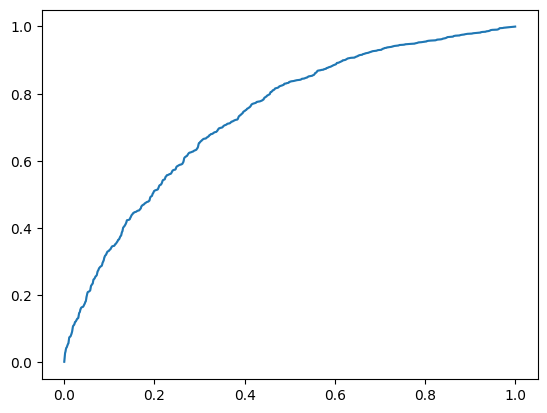

In [ ]:
# ROC Curve_Logistic Regression
sns.lineplot(x = fpr, y = tpr)

In [ ]:
#roc_auc_score
auc_score = roc_auc_score(y_test, y_proba)
print(auc_score)

0.7364682486906187


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Precision
precision = precision_score(y_test, y_predict)
# Recall (Sensitivity)
recall = recall_score(y_test, y_predict)
# F1 Score
f1 = f1_score(y_test, y_predict)

print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

Precision: 0.709
Recall (Sensitivity): 0.766
F1 Score: 0.736


In [ ]:
df_original = df.copy()

In [ ]:
# SVC

In [ ]:
from sklearn.svm import SVC

x = df_original[['destination', 'passenger', 'weather', 'temperature', 'time',
       'coupon_category', 'coupon_expiry', 'gender', 'age', 'marital_status',
       'has_children', 'education', 'occupation', 'income', 'bar_visits',
       'coffee_house_visits', 'take_out_frequency',
       'restaurant_visits_(<$20)', 'restaurant_visits_($20-$50)', 'coupon_5',
       'coupon_15', 'coupon_25', 'direction_same', 'direction_opp']]
y = df_original['accepted_coupon?']

cat_cols = x.select_dtypes(['category', 'object']).columns
x_encoded = pd.get_dummies(x, columns=cat_cols, drop_first=True)

In [ ]:
df_original = pd.concat([x_encoded,y], axis = 'columns')
df.head()

,destination,passenger,weather,temperature,time,coupon_category,coupon_expiry,gender,age,marital_status,...,coffee_house_visits,take_out_frequency,restaurant_visits_(<$20),restaurant_visits_($20-$50),coupon_5,coupon_15,coupon_25,direction_same,direction_opp,accepted_coupon?
1905,No Urgent Place,Friend(s),Sunny,≥80,Evening,Coffee House,2h,Male,31-35,Single,...,1~3,8+,1~3,0,1,0,0,0,1,1
6690,No Urgent Place,Alone,Sunny,≥80,Morning,Coffee House,2h,Male,21-25,Single,...,8+,0,1~3,0,1,0,0,0,1,1
7023,No Urgent Place,Friend(s),Sunny,≥80,Evening,Coffee House,1d,Female,50+,Divorced,...,4~8,8+,8+,0,1,0,0,0,1,1
11079,Work,Alone,Sunny,≥80,Morning,Restaurant($20-$50),2h,Female,36-40,Married partner,...,0,4~8,0,0,1,0,0,1,0,0
6705,Work,Alone,Sunny,≥80,Morning,Coffee House,1d,Male,21-25,Single,...,8+,0,1~3,0,1,1,0,1,0,1


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, stratify=y, random_state=42)

svm_model = SVC(probability=True)
svm_model.fit(x_train, y_train)

y_predict_svm = svm_model.predict(x_test)

In [ ]:
# Model Accuracy_SVM
accuracy_svm = accuracy_score(y_test, y_predict_svm)
accuracy_svm

0.7359085534095389

In [ ]:
# Finding out ROC Curve and ROC_AUC_Score of SVM
y_proba_svm = svm_model.predict_proba(x_test)[:, 1]
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_proba_svm)

<Axes: >

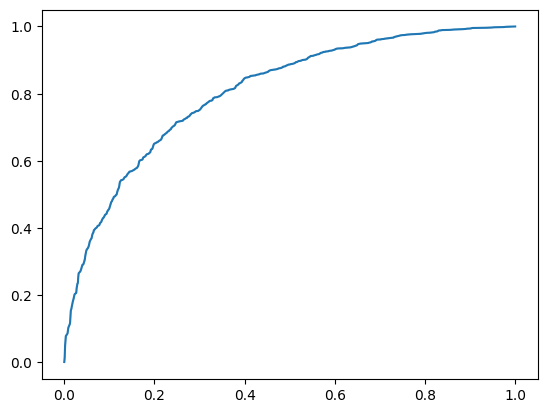

In [ ]:
# ROC Curve of SVM
sns.lineplot(x = fpr_svm, y = tpr_svm)

In [ ]:
#roc_auc_score of SVM
auc_score_svm = roc_auc_score(y_test, y_proba_svm)
print(auc_score_svm)

0.8053907877820633


In [ ]:
# Confusion_Matrix_SVM
conf_svm = confusion_matrix(y_test, y_predict_svm)
pd.DataFrame(conf_svm)

,0,1
0,705,390
1,280,1162


In [ ]:
# Precision, Recall and F1 Score of SVM
precision_svm = precision_score(y_test, y_predict_svm)
recall_svm= recall_score(y_test, y_predict_svm)
f1_svm = f1_score(y_test, y_predict_svm)

print(f"Precision_svm: {precision:.3f}")
print(f"Recall_svm: {recall:.3f}")
print(f"F1_Score_svm: {f1:.3f}")

Precision_svm: 0.709
Recall_svm: 0.766
F1_Score_svm: 0.736


In [ ]:
# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

x = df[['destination', 'passenger', 'weather', 'temperature', 'time',
        'coupon_category', 'coupon_expiry', 'gender', 'age', 'marital_status',
        'has_children', 'education', 'occupation', 'income', 'bar_visits',
        'coffee_house_visits', 'take_out_frequency',
        'restaurant_visits_(<$20)', 'restaurant_visits_($20-$50)', 'coupon_5',
        'coupon_15', 'coupon_25', 'direction_same', 'direction_opp']]
y = df['accepted_coupon?']

cat_cols = x.select_dtypes(['category', 'object']).columns
x_encoded = pd.get_dummies(x, columns=cat_cols, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, stratify=y, random_state=42)


dt_model = DecisionTreeClassifier(max_depth=10,random_state=42)
dt_model.fit(x_train, y_train)


DecisionTreeClassifier(max_depth=10, random_state=42)

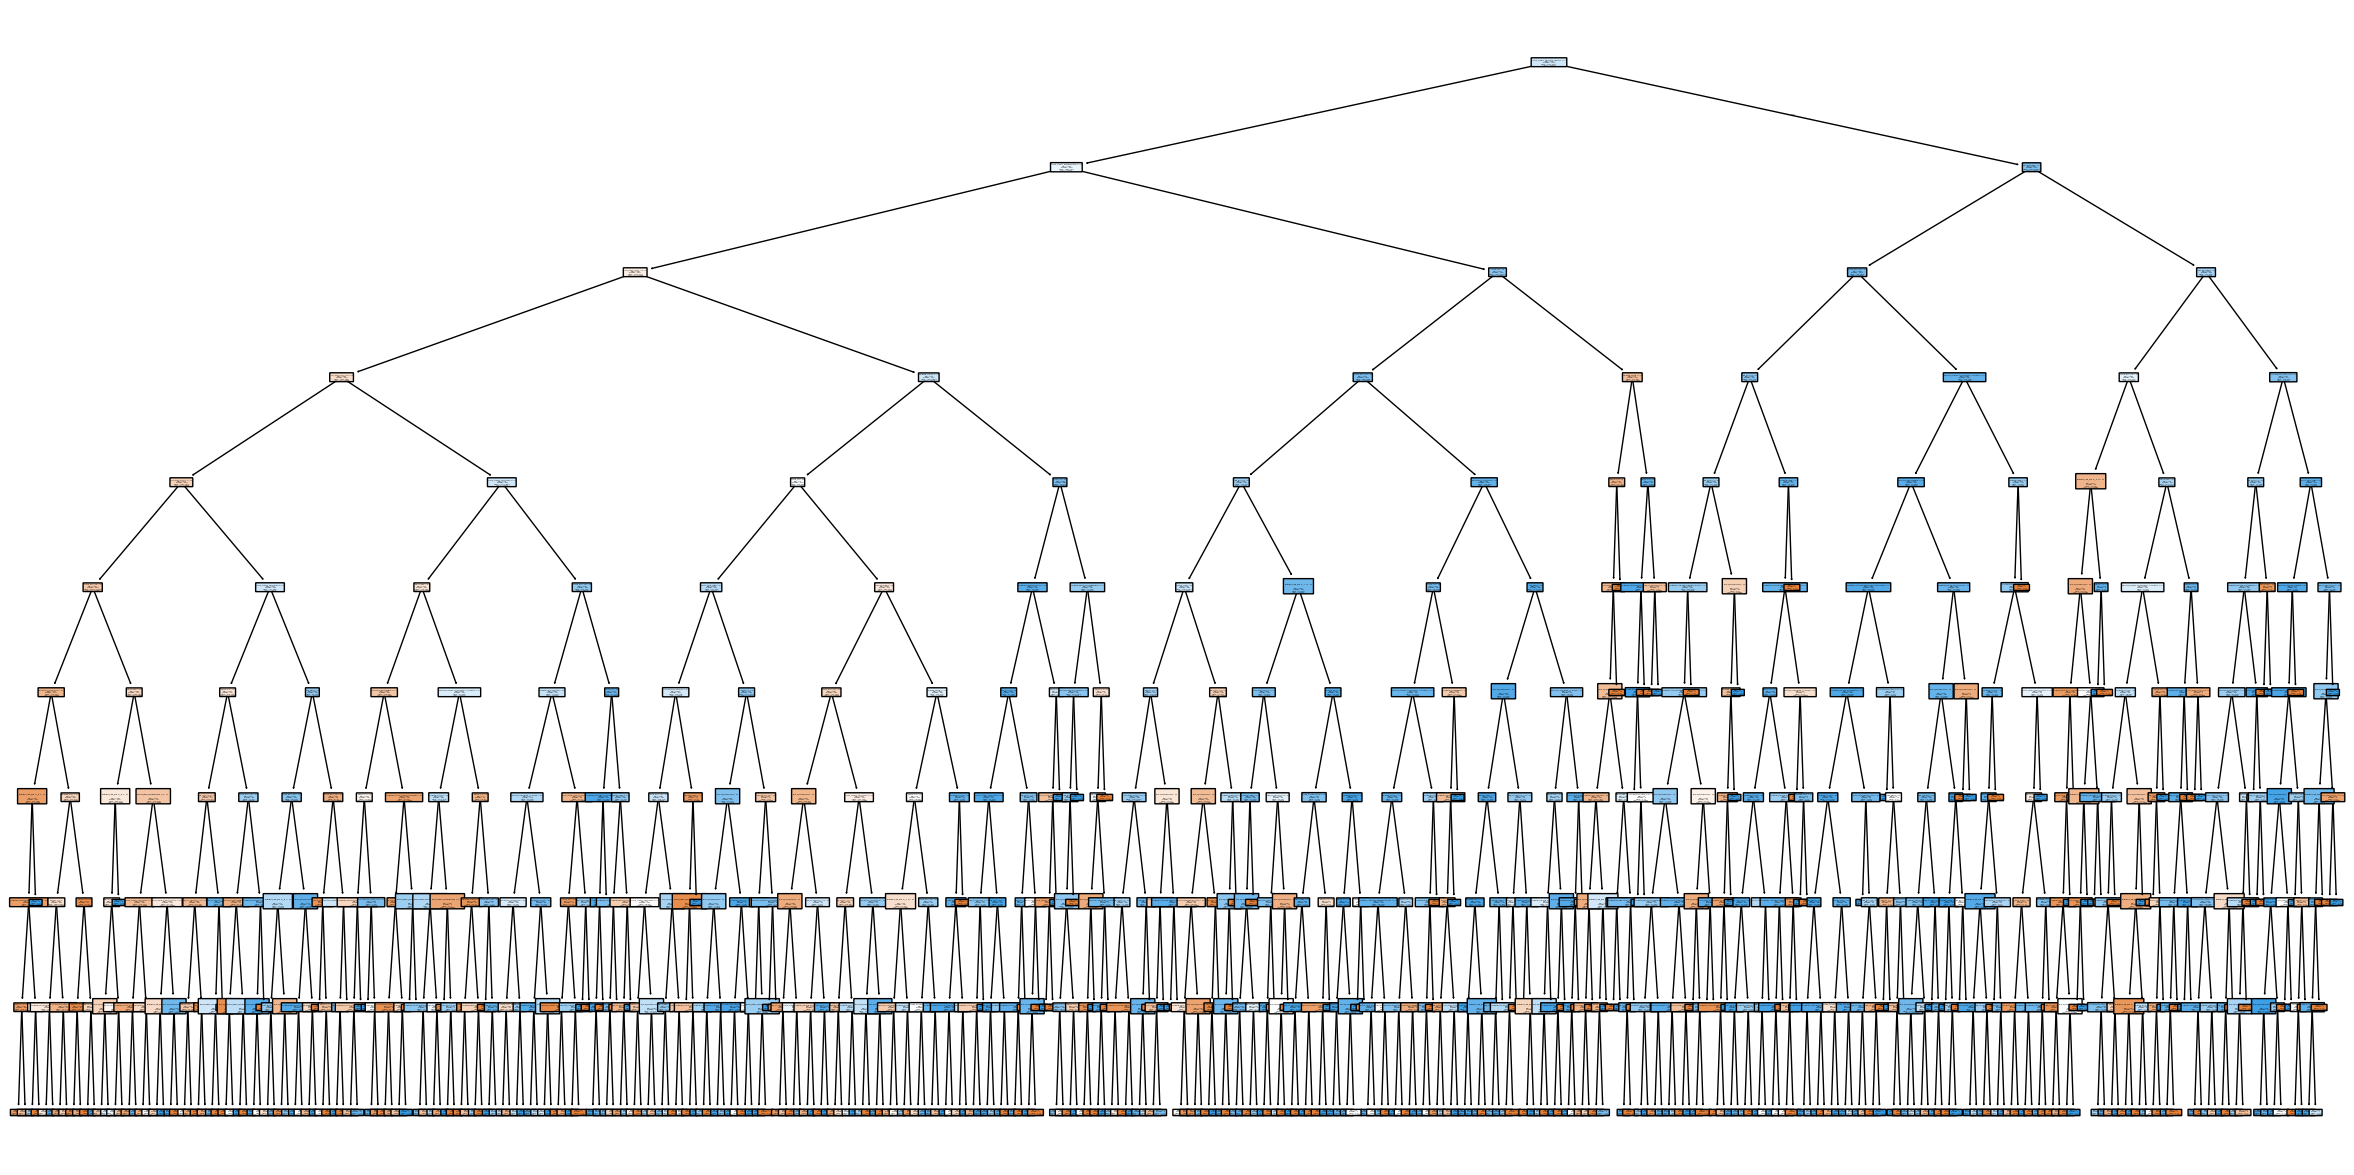

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30,15))
plot_tree(dt_model,
          filled=True,
          rounded=True,
          feature_names=x_encoded.columns,
          class_names={0:"Not Accepted", 1:"Accepted"})
plt.show()

In [ ]:
y_predict_dt = dt_model.predict(x_test)

In [ ]:
# Accuracy, Precision, Recall and F1 Score of the Decision Tree Model

accuracy_dt = accuracy_score(y_test, y_predict_dt)
precision_dt = precision_score(y_test, y_predict_dt)
recall_dt = recall_score(y_test, y_predict_dt)
f1_dt = f1_score(y_test, y_predict_dt)

print(f"Accuracy_dt: {accuracy_dt:.3f}")
print(f"Precision_dt: {precision_dt:.3f}")
print(f"Recall_dt: {recall_dt:.3f}")
print(f"F1_Score_dt: {f1_dt:.3f}")

Accuracy_dt: 0.679
Precision_dt: 0.725
Recall_dt: 0.701
F1_Score_dt: 0.713


In [ ]:
# Finding out ROC Curve and ROC_AUC_Score of DT
y_proba_dt = dt_model.predict_proba(x_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_proba_dt)

<Axes: >

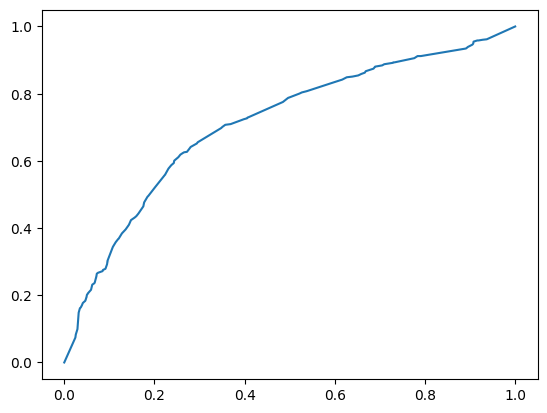

In [ ]:
# ROC Curve of DT
sns.lineplot(x = fpr_dt, y = tpr_dt)

In [ ]:
#roc_auc_score of DT
auc_score_dt = roc_auc_score(y_test, y_proba_dt)
print(auc_score_dt)

0.711469040335911


In [ ]:
# Confusion Matrix of the Decision Tree Model
conf_dt = confusion_matrix(y_test, y_predict_dt)
pd.DataFrame(conf_dt)

,0,1
0,711,384
1,431,1011


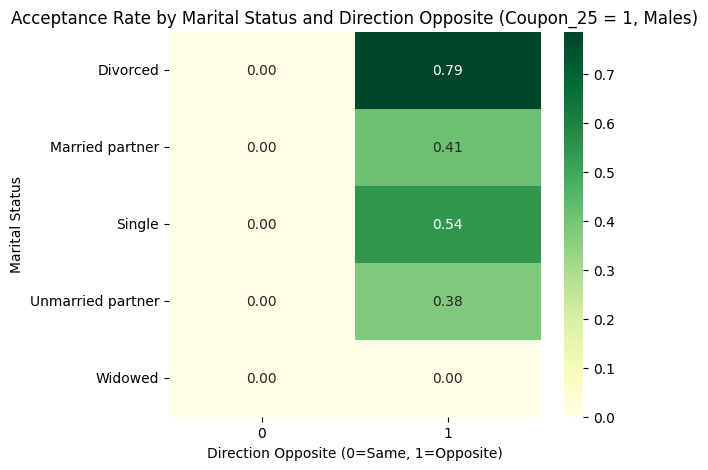

In [ ]:
df_male_coupon25 = df.loc[(df['gender'] == 'Male') & (df['coupon_25'] == 1)]
pivot_opp = df_male_coupon25.pivot_table(
    index='marital_status',
    columns='direction_opp',
    values='accepted_coupon?',
    aggfunc='mean')
pivot_opp = pivot_opp.reindex(columns=[0, 1], fill_value=0)

plt.figure(figsize=(6,5))
sns.heatmap(pivot_opp, annot=True, fmt=".2f", cmap='YlGn')
plt.title("Acceptance Rate by Marital Status and Direction Opposite (Coupon_25 = 1, Males)")
plt.ylabel("Marital Status")
plt.xlabel("Direction Opposite (0=Same, 1=Opposite)")
plt.show()

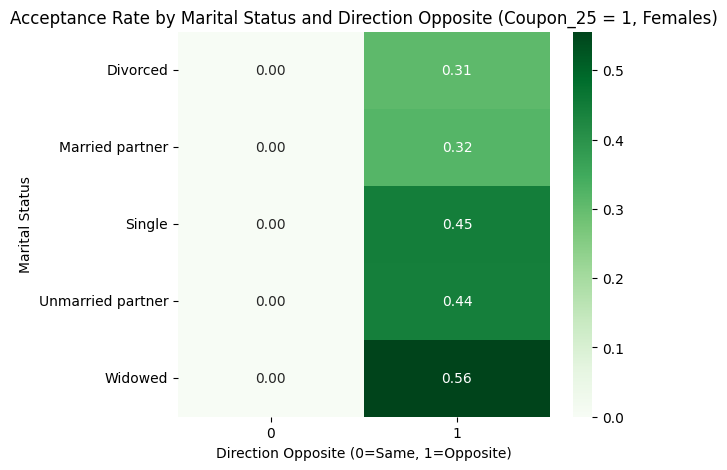

In [ ]:
df_female_coupon25 = df.loc[(df['gender'] == 'Female') & (df['coupon_25'] == 1)]

pivot = df_female_coupon25.pivot_table(index='marital_status', columns='direction_opp', values='accepted_coupon?', aggfunc='mean')
pivot = pivot.reindex(columns=[0, 1], fill_value=0)

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Greens')
plt.title("Acceptance Rate by Marital Status and Direction Opposite (Coupon_25 = 1, Females)")
plt.ylabel("Marital Status")
plt.xlabel("Direction Opposite (0=Same, 1=Opposite)")
plt.show()


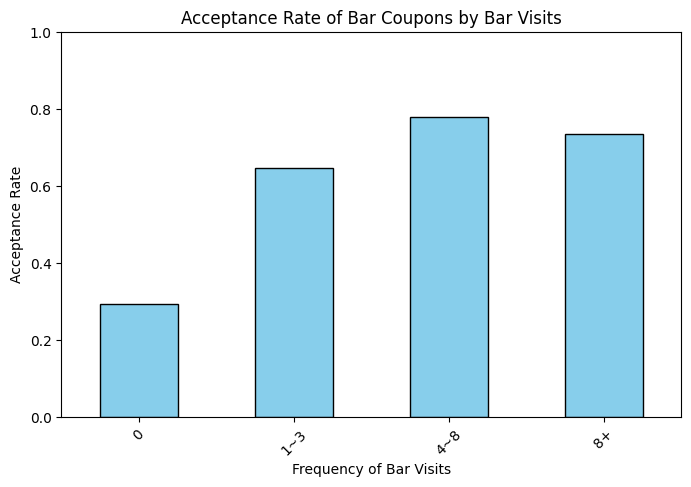

In [ ]:
df_bar = df.query("coupon_category == 'Bar'")
acceptance_rate = df_bar.groupby('bar_visits')['accepted_coupon?'].mean()

plt.figure(figsize=(8,5))
acceptance_rate.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Acceptance Rate of Bar Coupons by Bar Visits")
plt.ylabel("Acceptance Rate")
plt.xlabel("Frequency of Bar Visits")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

/tmp/ipython-input-2386317371.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_rate = df_carry.groupby('take_out_frequency')['accepted_coupon?'].mean()


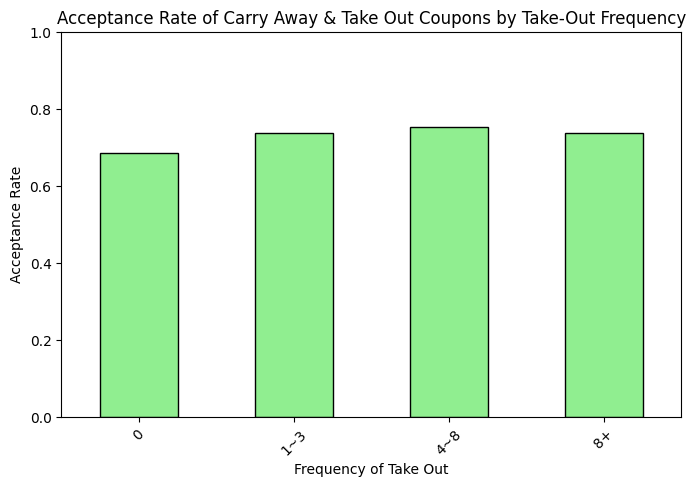

In [ ]:
df_carry = df.query("coupon_category == 'Carry out & Take away'")
acceptance_rate = df_carry.groupby('take_out_frequency')['accepted_coupon?'].mean()

plt.figure(figsize=(8,5))
acceptance_rate.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Acceptance Rate of Carry Away & Take Out Coupons by Take-Out Frequency")
plt.ylabel("Acceptance Rate")
plt.xlabel("Frequency of Take Out")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

/tmp/ipython-input-1054720620.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_rate = df_coffee.groupby('coffee_house_visits')['accepted_coupon?'].mean()


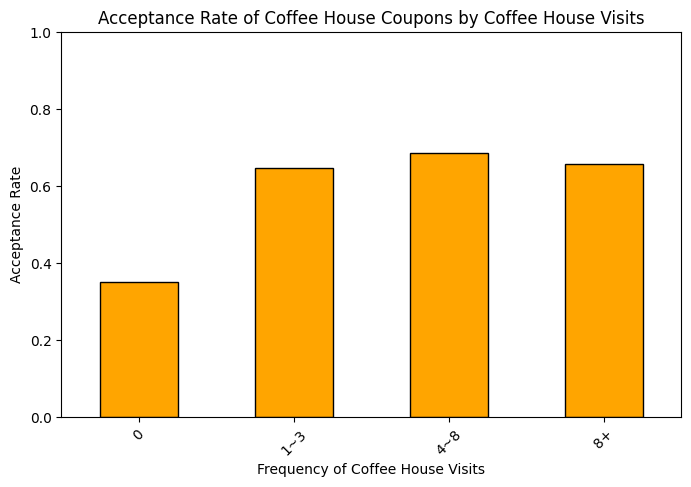

In [ ]:
df_coffee = df.query("coupon_category == 'Coffee House'")
acceptance_rate = df_coffee.groupby('coffee_house_visits')['accepted_coupon?'].mean()

plt.figure(figsize=(8,5))
acceptance_rate.plot(kind='bar', color='orange', edgecolor='black')
plt.title("Acceptance Rate of Coffee House Coupons by Coffee House Visits")
plt.ylabel("Acceptance Rate")
plt.xlabel("Frequency of Coffee House Visits")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

/tmp/ipython-input-2819714243.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_rate = df_rest20.groupby('restaurant_visits_(<$20)')['accepted_coupon?'].mean()


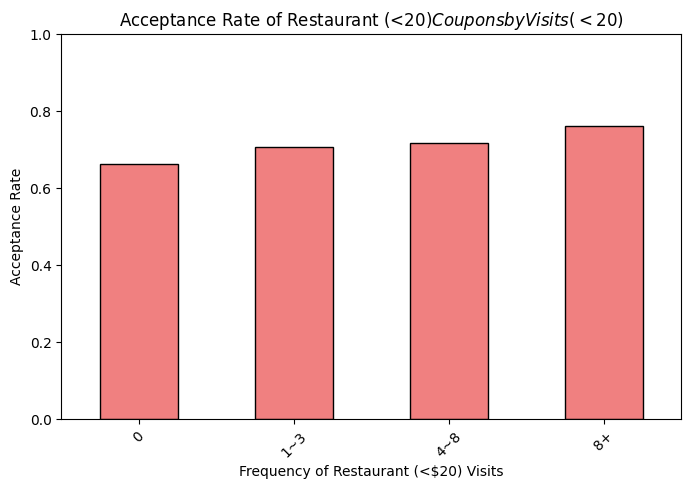

In [ ]:
df_rest20 = df.query("coupon_category == 'Restaurant(<$20)'")
acceptance_rate = df_rest20.groupby('restaurant_visits_(<$20)')['accepted_coupon?'].mean()

plt.figure(figsize=(8,5))
acceptance_rate.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title("Acceptance Rate of Restaurant (<$20) Coupons by Visits (<$20)")
plt.ylabel("Acceptance Rate")
plt.xlabel("Frequency of Restaurant (<$20) Visits")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

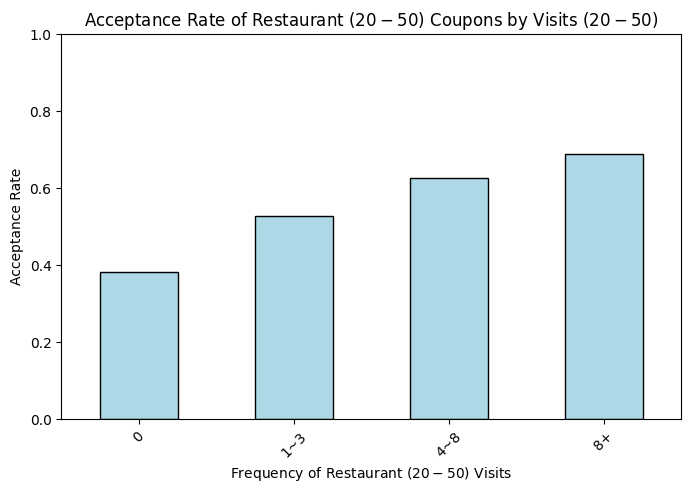

In [ ]:
df_rest2050 = df.query("coupon_category == 'Restaurant($20-$50)'")
acceptance_rate = df_rest2050.groupby('restaurant_visits_($20-$50)')['accepted_coupon?'].mean()

plt.figure(figsize=(8,5))
acceptance_rate.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title("Acceptance Rate of Restaurant ($20-$50) Coupons by Visits ($20-$50)")
plt.ylabel("Acceptance Rate")
plt.xlabel("Frequency of Restaurant ($20-$50) Visits")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

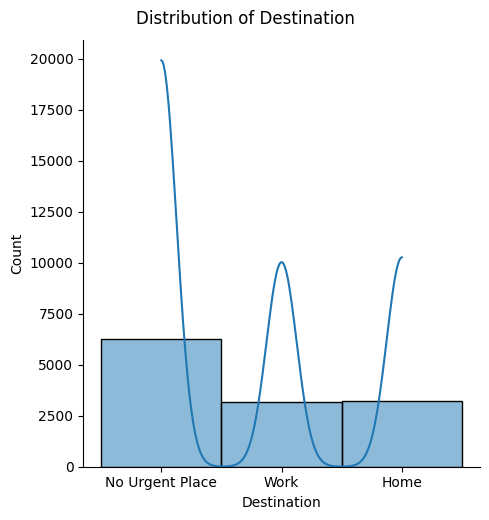

In [ ]:
g = sns.displot(data=df, x='destination', kde=True)
g.set_axis_labels("Destination", "Count")
g.fig.suptitle("Distribution of Destination", y=1.03)
plt.show()

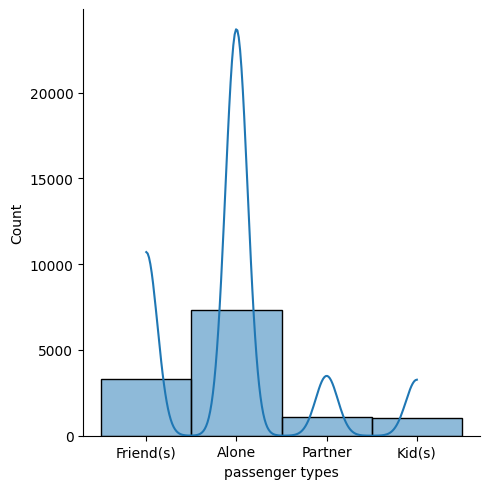

In [ ]:
g = sns.displot(data=df, x='passenger', kde=True)
g.set_axis_labels("passenger types", "Count")
plt.show()

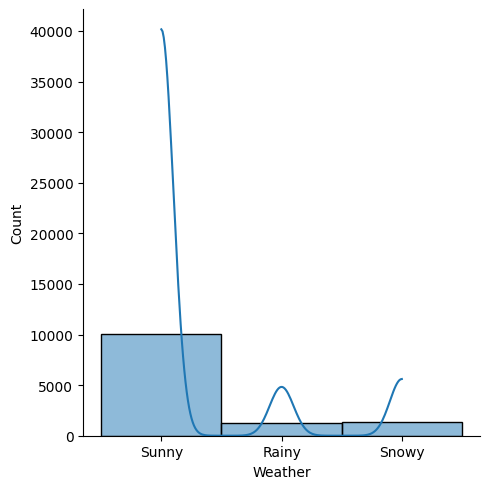

In [ ]:
g = sns.displot(data=df, x='weather', kde=True)
g.set_axis_labels("Weather", "Count")
plt.show()

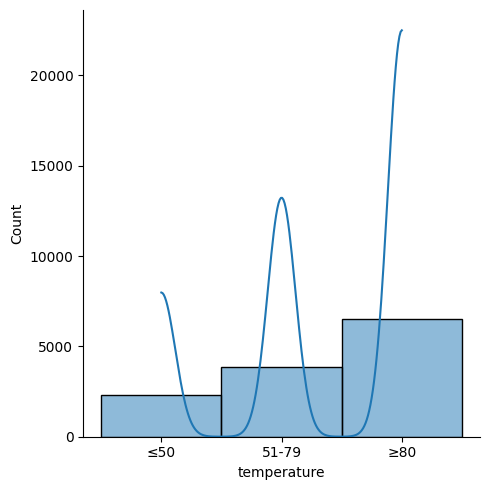

In [ ]:
g = sns.displot(data=df, x='temperature', kde=True)
g.set_axis_labels("temperature", "Count")
plt.show()

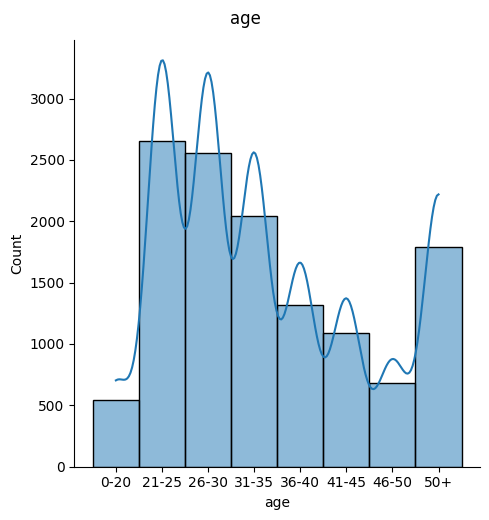

In [ ]:
g = sns.displot(data=df, x='age', kde=True)
g.set_axis_labels("age", "Count")
g.fig.suptitle("age", y=1.03)
plt.show()

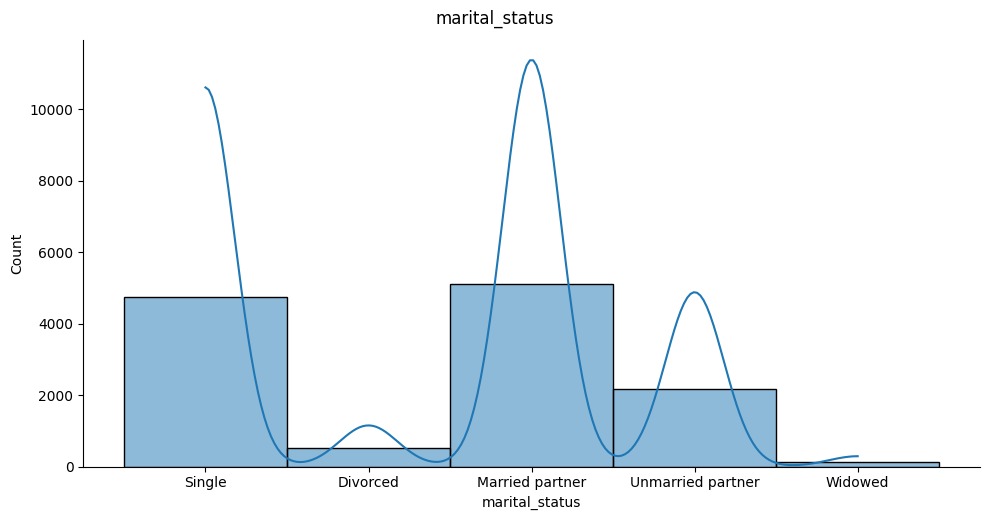

In [ ]:
g = sns.displot(data=df, x='marital_status', kde=True, aspect=2)
g.set_axis_labels("marital_status", "Count")
g.fig.suptitle("marital_status", y=1.03)
plt.show()

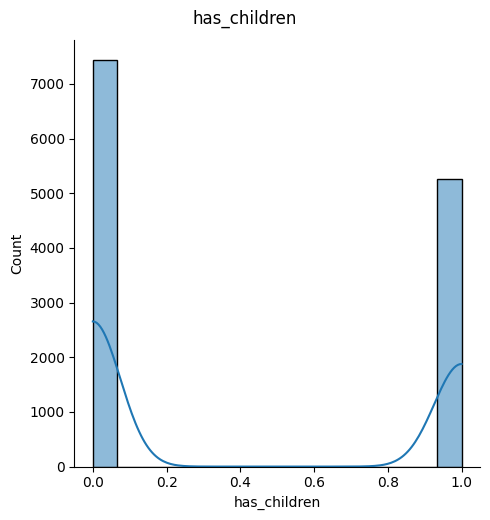

In [ ]:
g = sns.displot(data=df, x='has_children', kde=True)
g.set_axis_labels("has_children", "Count")
g.fig.suptitle("has_children", y=1.03)
plt.show()

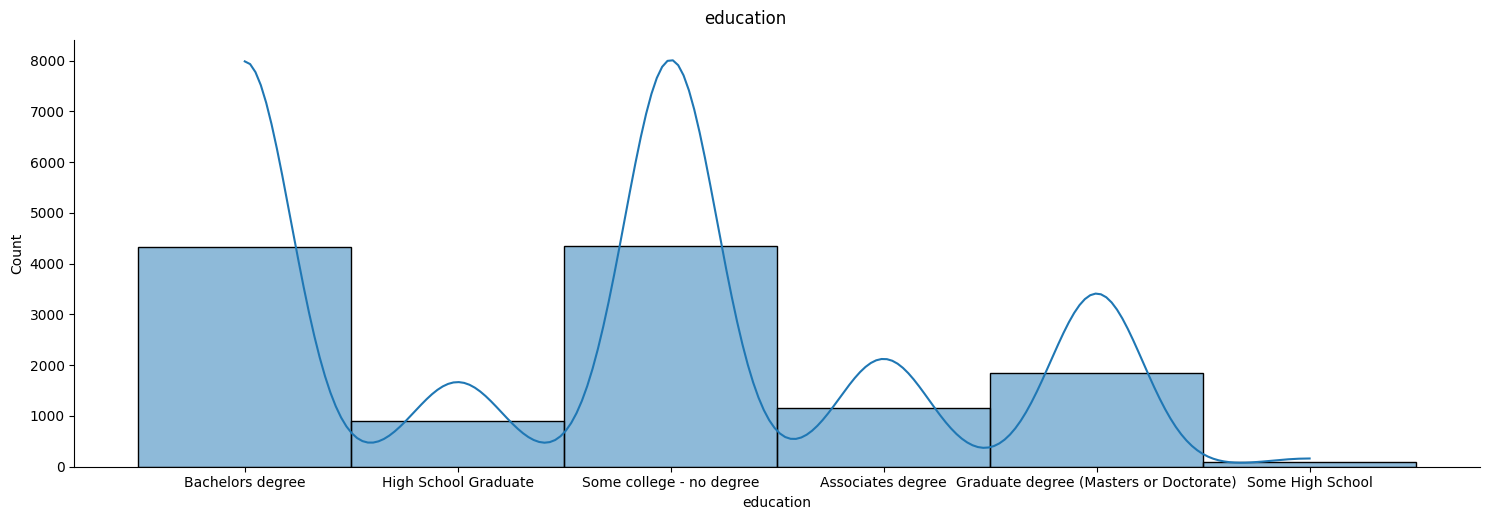

In [ ]:
g = sns.displot(data=df, x='education', kde=True, aspect=3)
g.set_axis_labels("education", "Count")
g.fig.suptitle("education", y=1.03)
plt.show()

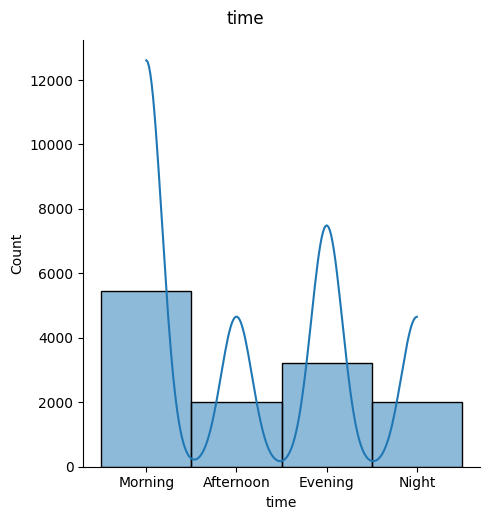

In [ ]:
g = sns.displot(data=df, x='time', kde=True)
g.set_axis_labels("time", "Count")
g.fig.suptitle("time", y=1.03)
plt.show()

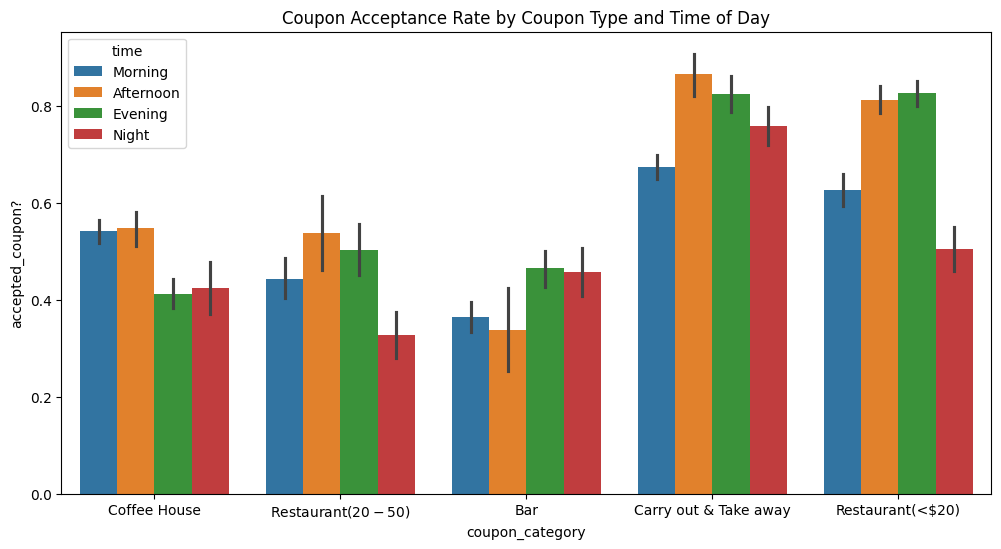

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x="coupon_category",
    y="accepted_coupon?",
    hue="time"
)
plt.title("Coupon Acceptance Rate by Coupon Type and Time of Day")
plt.show()

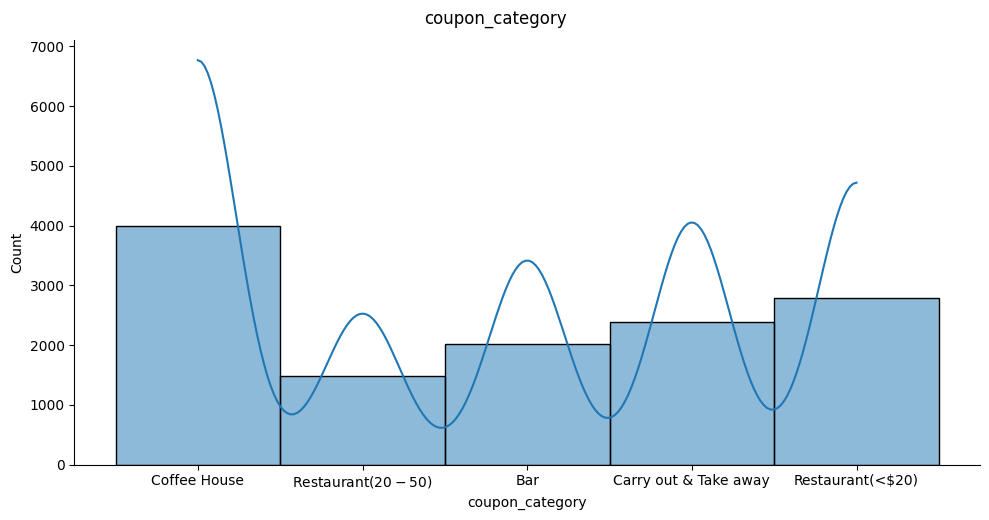

In [ ]:
g = sns.displot(data=df, x='coupon_category', kde=True, aspect=2)
g.set_axis_labels("coupon_category", "Count")
g.fig.suptitle("coupon_category", y=1.03)
plt.show()

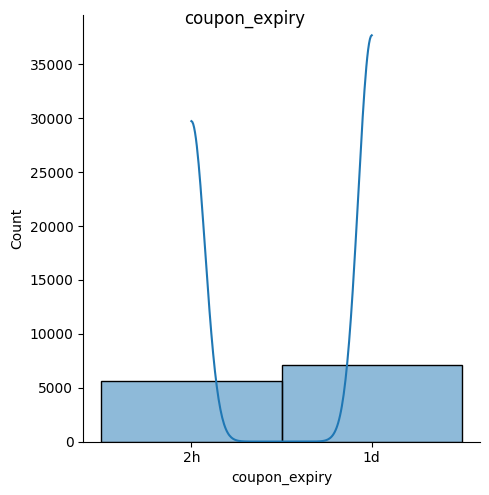

In [ ]:
g = sns.displot(data=df, x='coupon_expiry', kde=True)
g.set_axis_labels("coupon_expiry", "Count")
g.fig.suptitle("coupon_expiry")
plt.show()

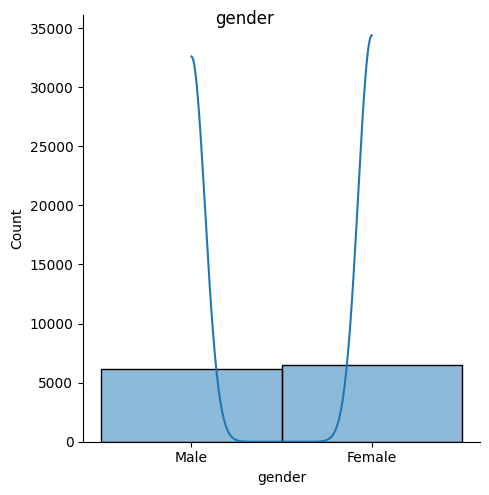

In [ ]:
g = sns.displot(data=df, x='gender', kde=True)
g.set_axis_labels("gender", "Count")
g.fig.suptitle("gender")
plt.show()

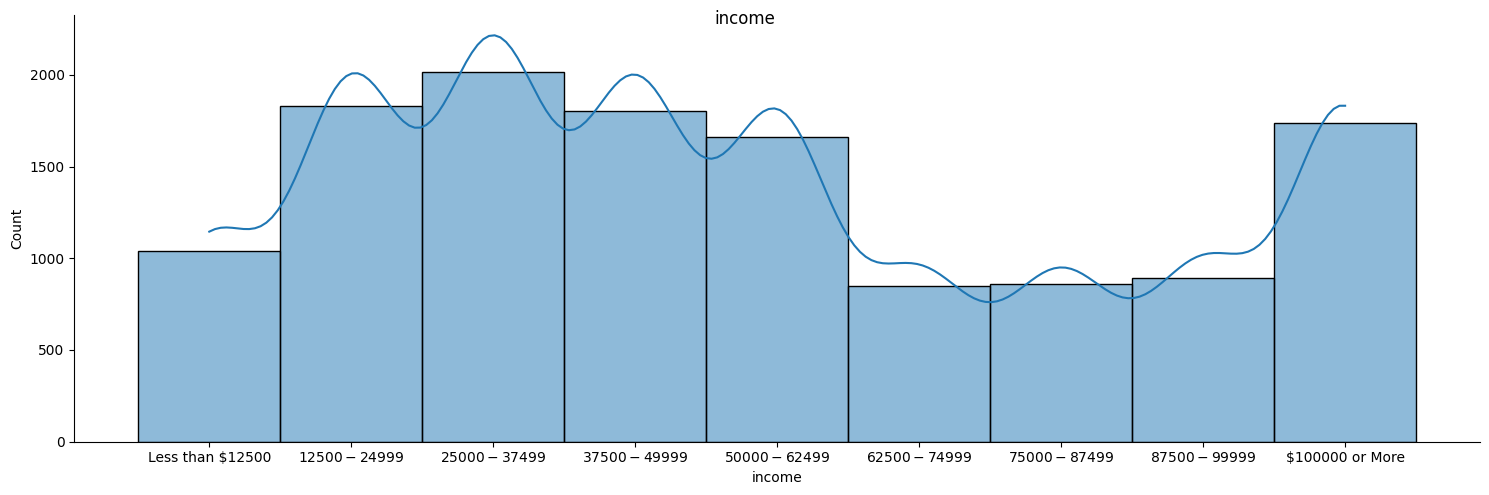

In [ ]:
g = sns.displot(data=df, x='income', kde=True,aspect=3)
g.set_axis_labels("income", "Count")
g.fig.suptitle("income")
plt.show()

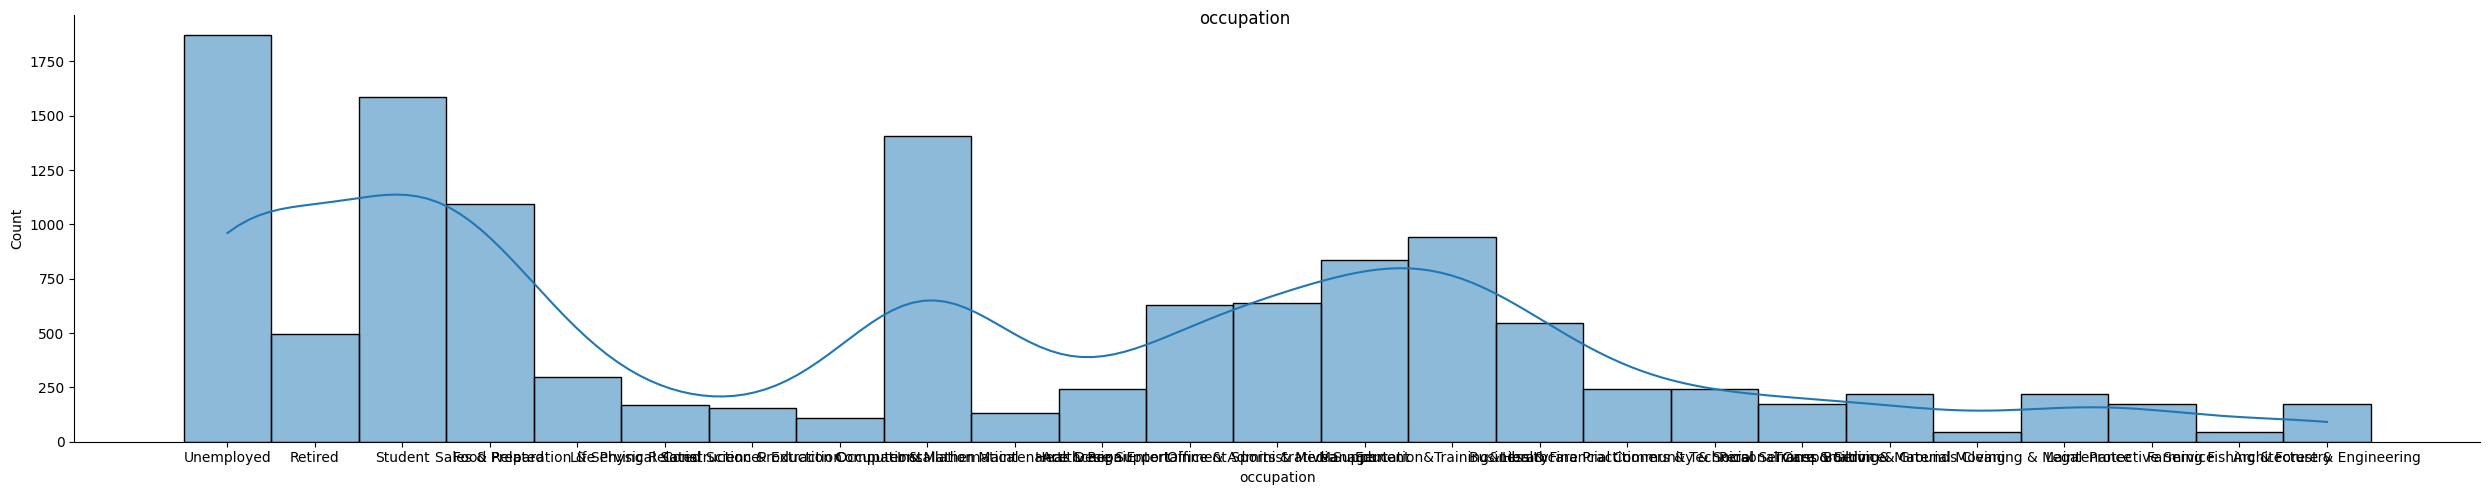

In [ ]:
g = sns.displot(data=df, x='occupation', kde=True,aspect=5)
g.set_axis_labels("occupation", "Count")
g.fig.suptitle("occupation")
plt.show()

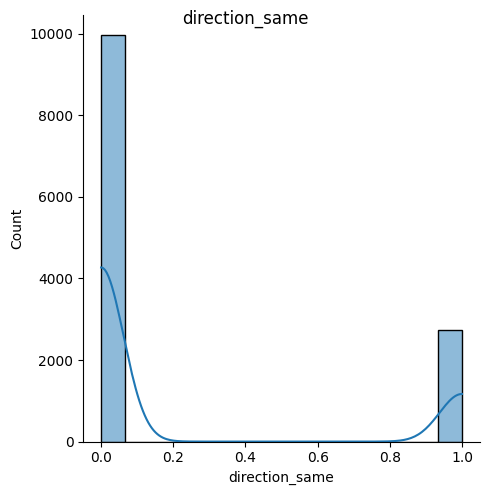

In [ ]:
g = sns.displot(data=df, x='direction_same', kde=True)
g.set_axis_labels("direction_same", "Count")
g.fig.suptitle("direction_same")
plt.show()

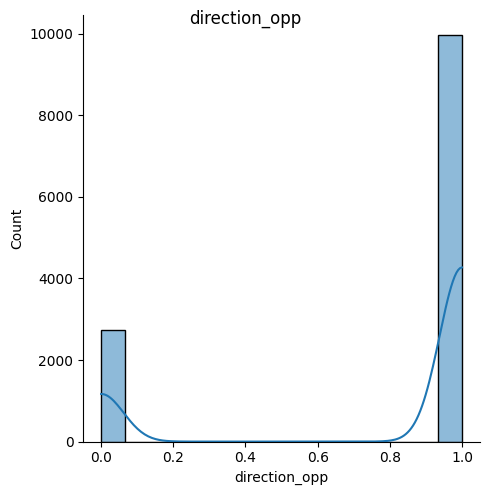

In [ ]:
g = sns.displot(data=df, x='direction_opp', kde=True)
g.set_axis_labels("direction_opp", "Count")
g.fig.suptitle("direction_opp")
plt.show()


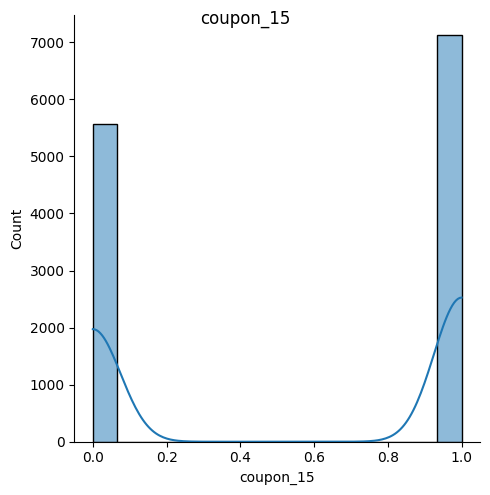

In [ ]:
g = sns.displot(data=df, x='coupon_15', kde=True)
g.set_axis_labels("coupon_15", "Count")
g.fig.suptitle("coupon_15")
plt.show()

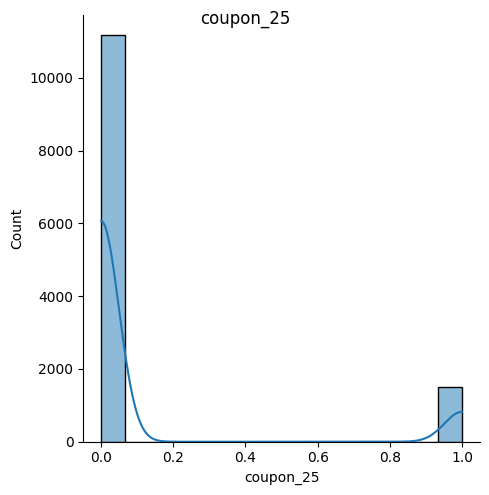

In [ ]:
g = sns.displot(data=df, x='coupon_25', kde=True)
g.set_axis_labels("coupon_25", "Count")
g.fig.suptitle("coupon_25")
plt.show()

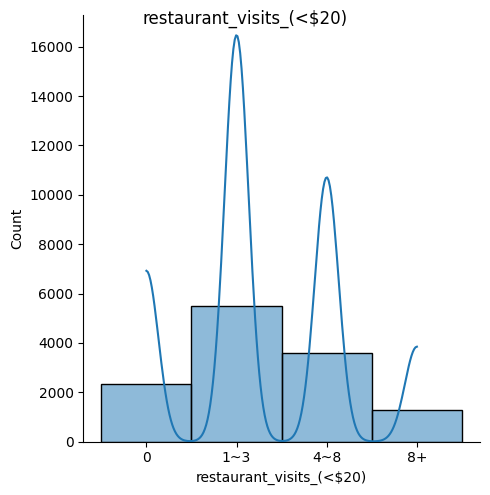

In [ ]:
g = sns.displot(data=df, x='restaurant_visits_(<$20)', kde=True)
g.set_axis_labels("restaurant_visits_(<$20)", "Count")
g.fig.suptitle("restaurant_visits_(<$20)")
plt.show()

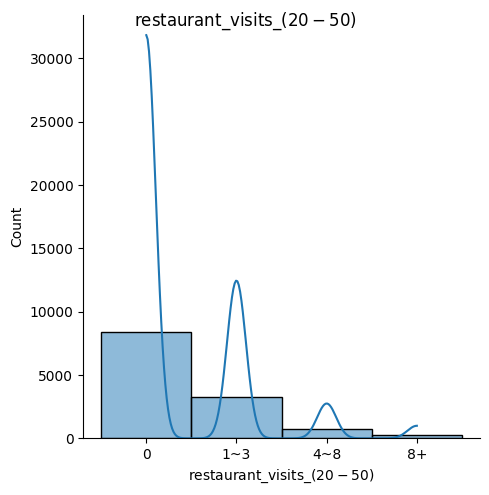

In [ ]:
g = sns.displot(data=df, x='restaurant_visits_($20-$50)', kde=True)
g.set_axis_labels("restaurant_visits_($20-$50)", "Count")
g.fig.suptitle("restaurant_visits_($20-$50)")
plt.show()

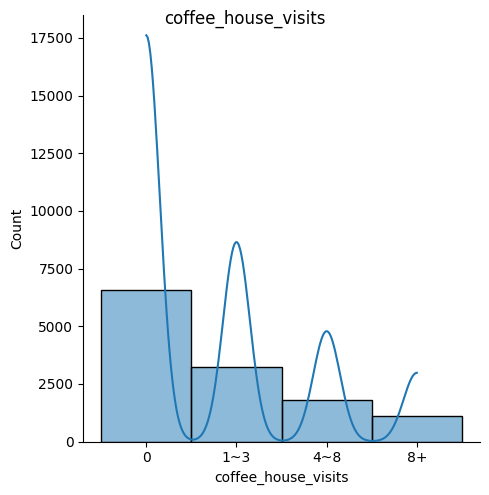

In [ ]:
g = sns.displot(data=df, x='coffee_house_visits', kde=True)
g.set_axis_labels("coffee_house_visits", "Count")
g.fig.suptitle("coffee_house_visits")
plt.show()

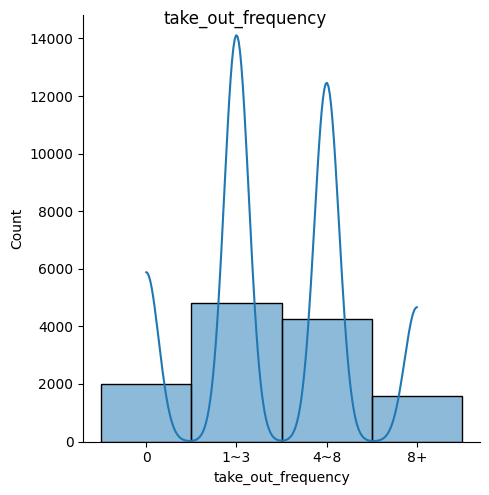

In [ ]:
g = sns.displot(data=df, x='take_out_frequency', kde=True)
g.set_axis_labels("take_out_frequency", "Count")
g.fig.suptitle("take_out_frequency")
plt.show()

In [ ]:
# Top_5_Occupations
occupation_rates = df.groupby("occupation")["accepted_coupon?"].mean().sort_values(ascending=False)
top5_occupations = occupation_rates.head(5)
df_top5 = df.loc[df["occupation"].isin(top5_occupations.index)]
print(top5_occupations)

occupation
Healthcare Support                      0.698347
Construction & Extraction               0.688312
Healthcare Practitioners & Technical    0.676230
Protective Service                      0.645714
Architecture & Engineering              0.634286
Name: accepted_coupon?, dtype: float64


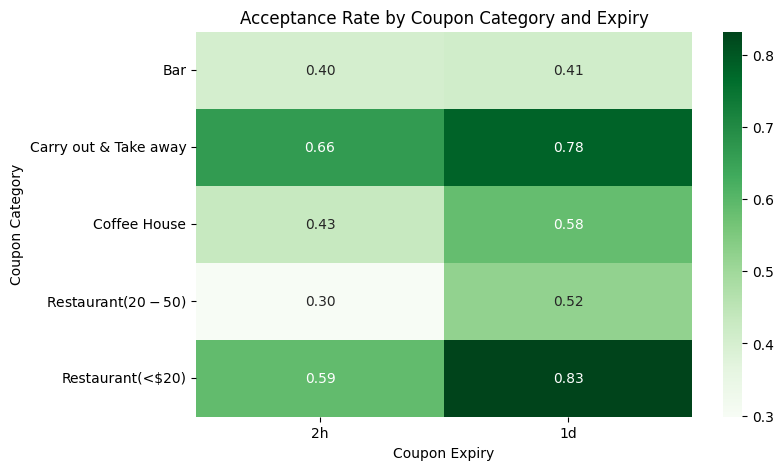

In [ ]:
ct = pd.crosstab(df['coupon_category'], df['coupon_expiry'], values=df['accepted_coupon?'], aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap='Greens')
plt.title('Acceptance Rate by Coupon Category and Expiry')
plt.ylabel('Coupon Category')
plt.xlabel('Coupon Expiry')
plt.show()

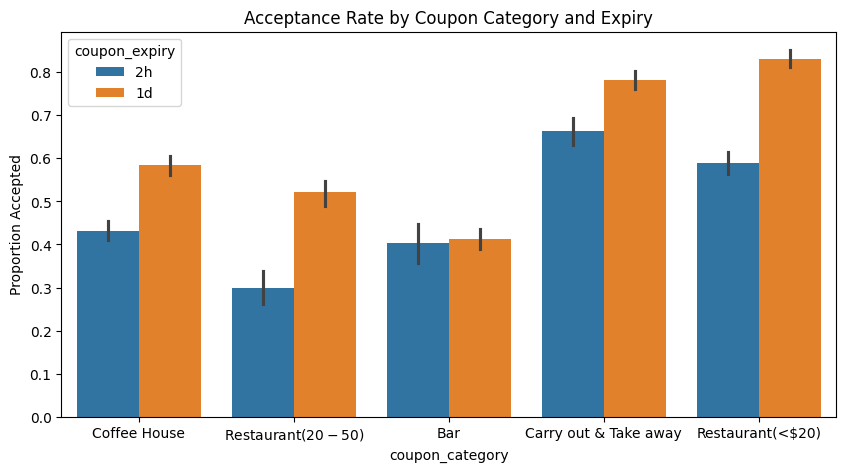

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='coupon_category', y='accepted_coupon?', hue='coupon_expiry', data=df, estimator=np.mean)
plt.title('Acceptance Rate by Coupon Category and Expiry')
plt.ylabel('Proportion Accepted')
plt.show()

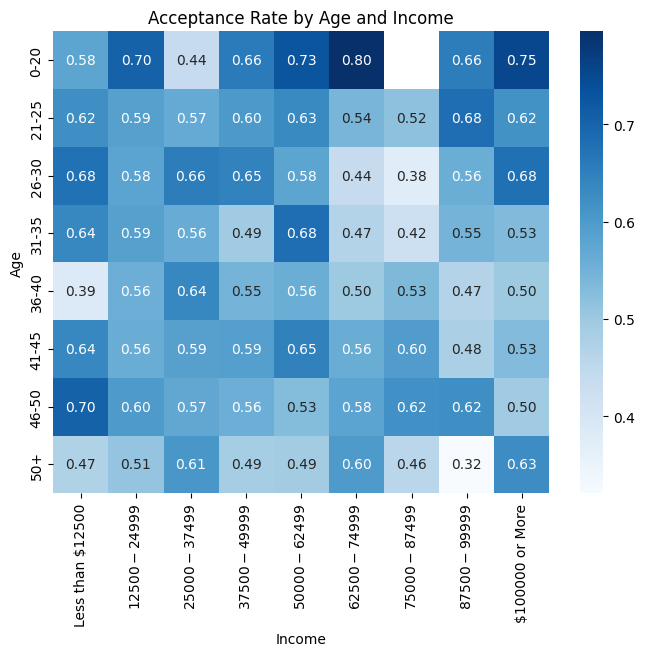

In [ ]:
ct = pd.crosstab(df['age'], df['income'], values=df['accepted_coupon?'], aggfunc='mean')
plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt=".2f", cmap='Blues')
plt.title('Acceptance Rate by Age and Income')
plt.ylabel('Age')
plt.xlabel('Income')
plt.show()

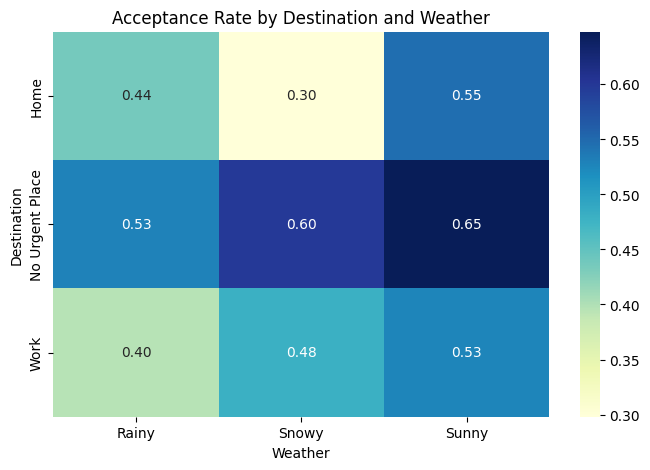

In [ ]:
ct = pd.crosstab(df['destination'], df['weather'], values=df['accepted_coupon?'], aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Acceptance Rate by Destination and Weather')
plt.ylabel('Destination')
plt.xlabel('Weather')
plt.show()

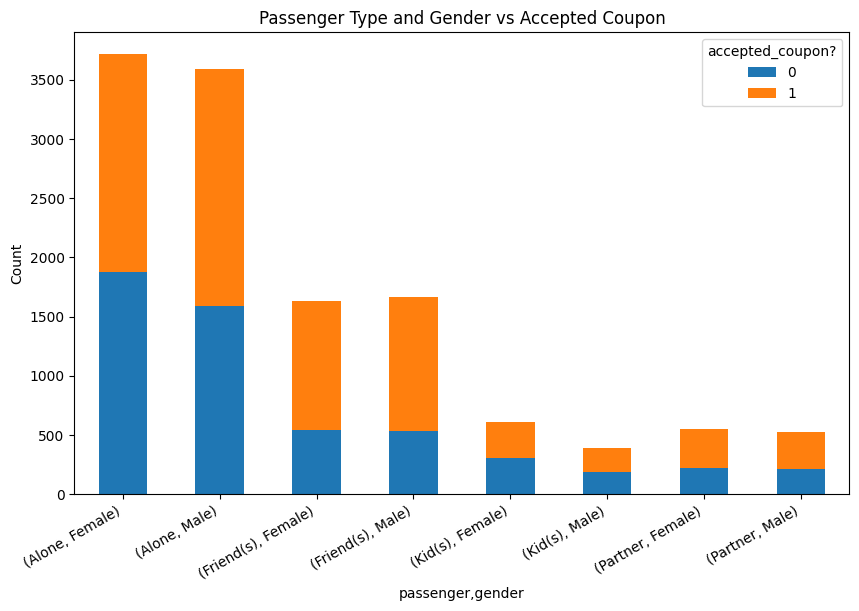

In [ ]:
stacked_data = df.groupby(['passenger','gender','accepted_coupon?']).size().unstack(fill_value=0)

stacked_data.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Passenger Type and Gender vs Accepted Coupon")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.show()

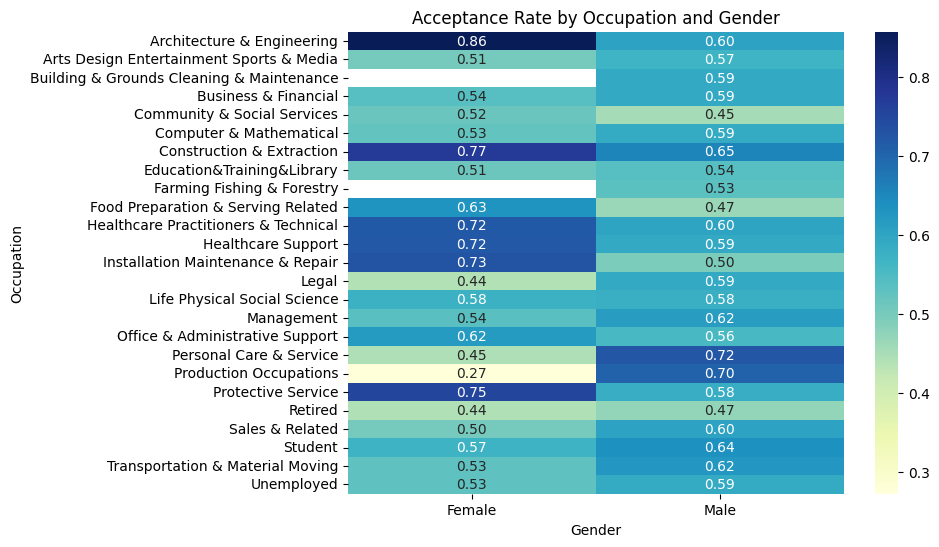

In [ ]:
pivot = pd.crosstab(df['occupation'], df['gender'],
                    values=df['accepted_coupon?'], aggfunc='mean')
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("Acceptance Rate by Occupation and Gender")
plt.ylabel("Occupation")
plt.xlabel("Gender")
plt.show()

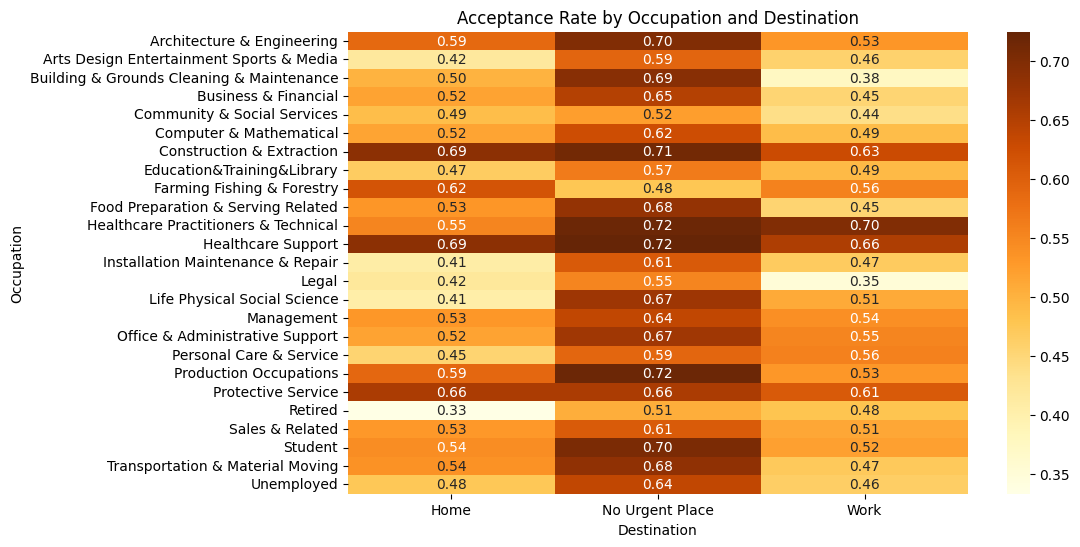

In [ ]:
pivot = pd.crosstab(df['occupation'], df['destination'],
                    values=df['accepted_coupon?'], aggfunc='mean')
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlOrBr')
plt.title("Acceptance Rate by Occupation and Destination")
plt.ylabel("Occupation")
plt.xlabel("Destination")
plt.show()

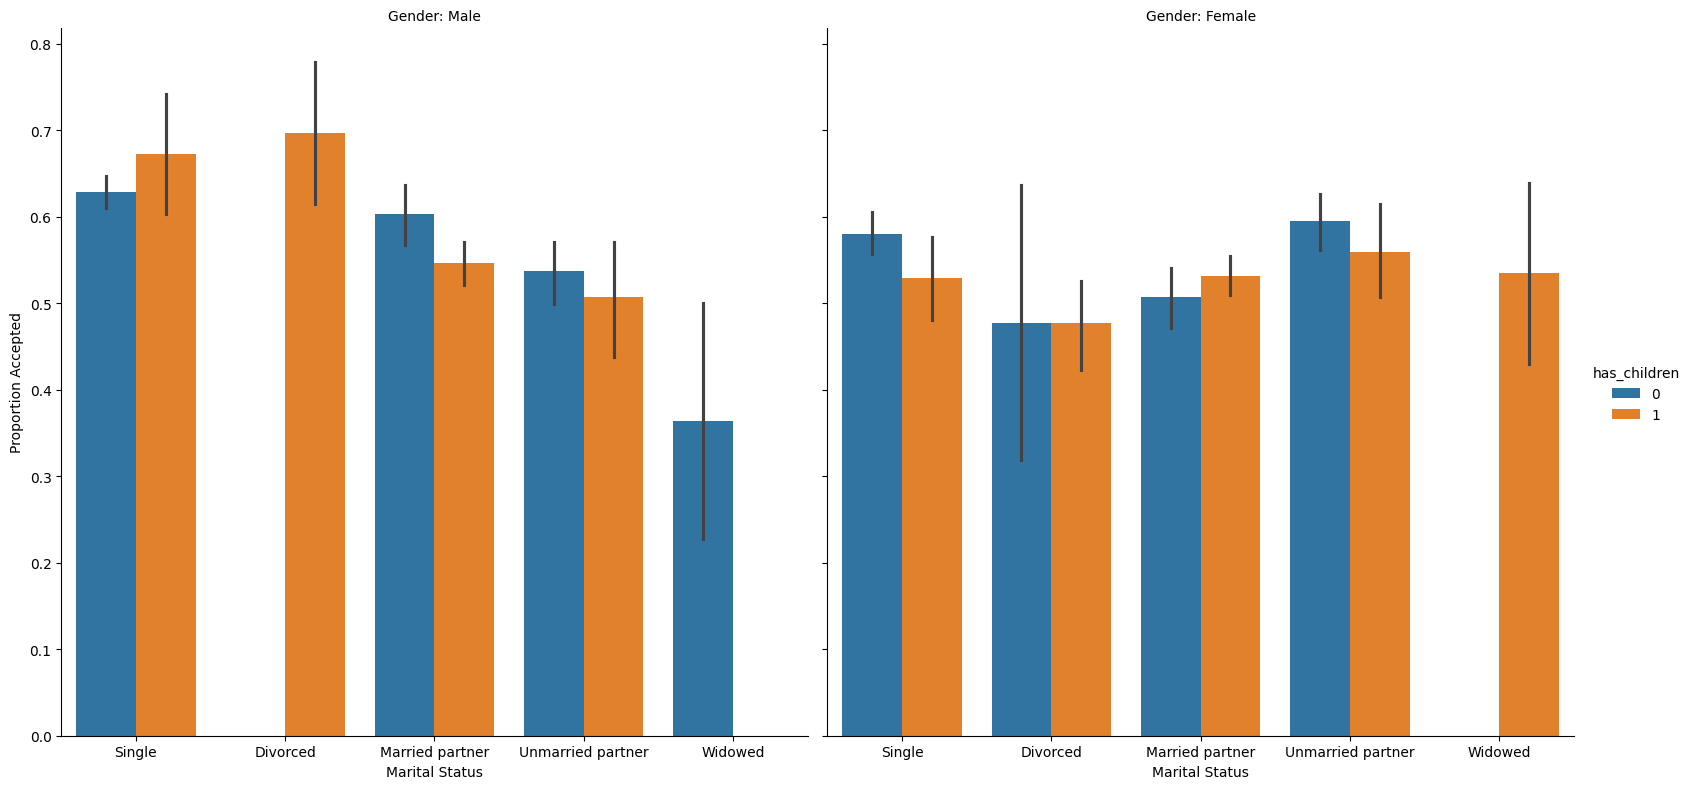

In [ ]:
g = sns.catplot(
    x='marital_status',
    y='accepted_coupon?',
    hue='has_children',
    col='gender',        # separate plots by gender
    data=df,
    kind='bar',
    estimator=np.mean,
    height=8,
    aspect=1
)

g.set_axis_labels("Marital Status", "Proportion Accepted")
g.set_titles("Gender: {col_name}")
plt.show()

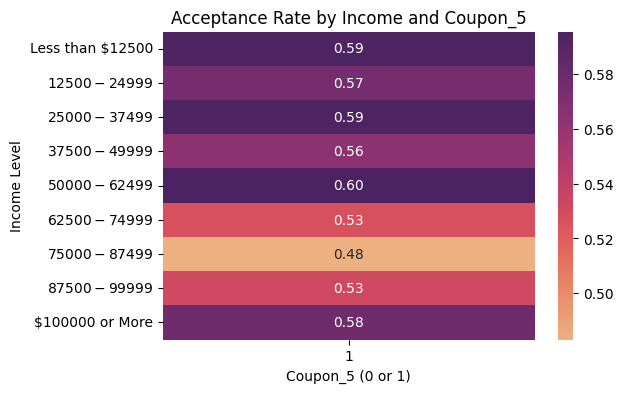

In [ ]:
pivot = pd.crosstab(df['income'], df['coupon_5'], values=df['accepted_coupon?'], aggfunc='mean')
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='flare')
plt.title("Acceptance Rate by Income and Coupon_5")
plt.ylabel("Income Level")
plt.xlabel("Coupon_5 (0 or 1)")
plt.show()

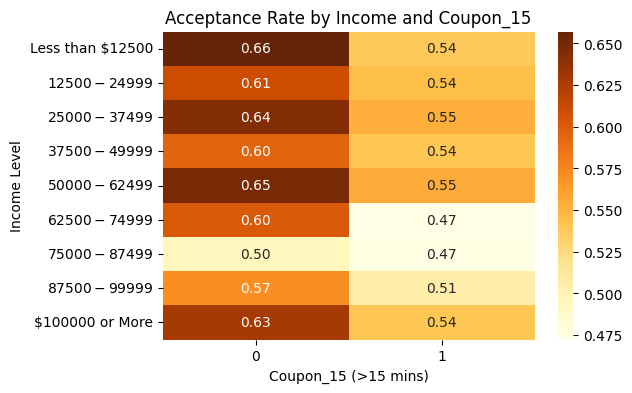

In [ ]:
pivot = pd.crosstab(df['income'], df['coupon_15'], values=df['accepted_coupon?'], aggfunc='mean')
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlOrBr')
plt.title("Acceptance Rate by Income and Coupon_15")
plt.ylabel("Income Level")
plt.xlabel("Coupon_15 (>15 mins)")
plt.show()

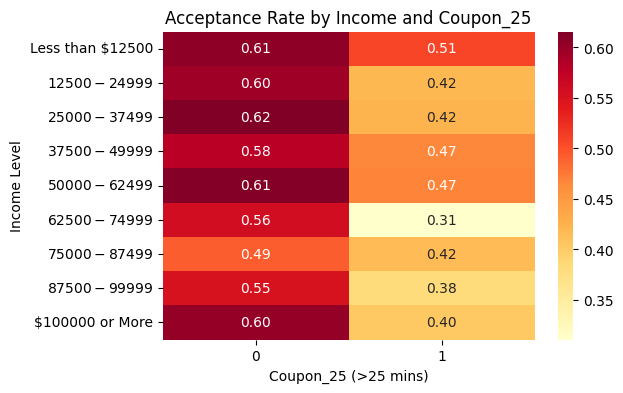

In [ ]:
pivot = pd.crosstab(df['income'], df['coupon_25'], values=df['accepted_coupon?'], aggfunc='mean')
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlOrRd')
plt.title("Acceptance Rate by Income and Coupon_25")
plt.ylabel("Income Level")
plt.xlabel("Coupon_25 (>25 mins)")
plt.show()